In [4]:
import pickle
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.stats import linregress
from fooof import FOOOF

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_21162/3787181349.py:6: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [5]:

with open('long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Flatten all days into one dict
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        key = f"{date_folder}/{session}"
        all_long_combined[key] = files

print(f"Combined: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")

Combined: 18 sessions, 366 files


In [ ]:
with open('short_data.pkl', 'rb') as f:
    short_data = pickle.load(f)


In [6]:
all_long_combined["20220309/111051"]["Data0001.mat"]["Params"]["Fs"]



array([[1000.]])

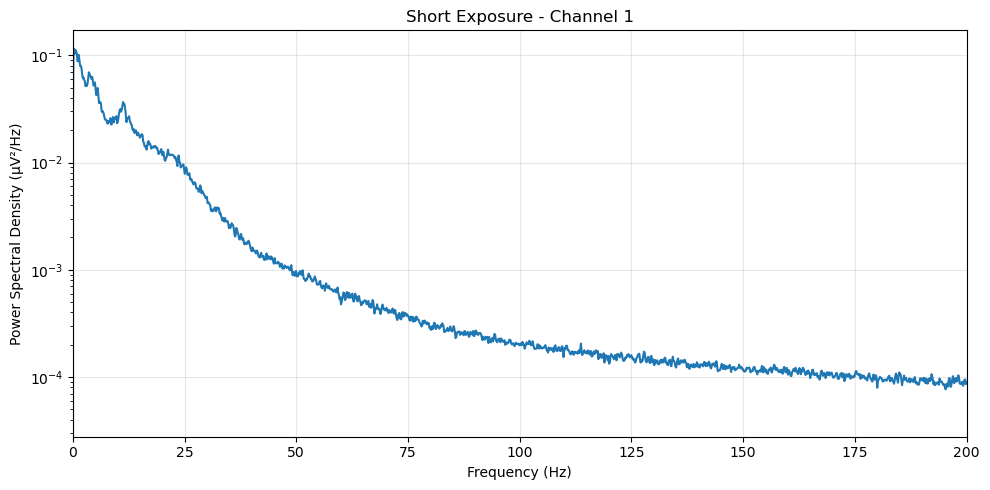

In [12]:

def plot_power_spectrum(all_data, channel=1, fs=1000, title='Power Spectrum'):
    """
    Plot PSD from BroadbandData for a given channel.
    Concatenates all time bins across all trials into one continuous signal,
    then computes PSD via Welch's method.
    
    channel: 1-indexed channel number (1-128)
    fs: sampling rate in Hz
    """
    n_channels = 128
    signal_chunks = []

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            broadband = mat_file['BroadbandData']
            for bin_data in broadband:
                n_samples = len(bin_data) // n_channels
                reshaped = bin_data[:n_channels * n_samples].reshape(n_channels, n_samples)
                signal_chunks.append(reshaped[channel - 1, :])

    signal = np.concatenate(signal_chunks)

    freqs, psd = welch(signal, fs=fs, nperseg=6667)

    plt.figure(figsize=(10, 5))
    plt.semilogy(freqs, psd)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectral Density (µV²/Hz)')
    plt.title(f'{title} - Channel {channel}')
    plt.xlim([0, 200])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_power_spectrum(short_data, channel=1, title='Short Exposure')

In [ ]:
def plot_power_corrected(
    all_data,
    channel=6,
    fs=1000,
    nperseg=6667,
    title='Power Spectrum',
    fit_range=(1, 200),
    line_freq=60,
    line_exclusion_hz=2,
):
    """
    Plot PSD with 1/f correction for a given channel.

    The 1/f slope is fit in log-log space across the entire frequency range
    (default 1-200 Hz) to get a broadband average 1/f baseline.
    """
    n_channels = 128
    signal_chunks = []

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            broadband = mat_file['BroadbandData']
            for bin_data in broadband:
                n_samples = len(bin_data) // n_channels
                reshaped = bin_data[:n_channels * n_samples].reshape(n_channels, n_samples)
                signal_chunks.append(reshaped[channel - 1, :])

    signal = np.concatenate(signal_chunks)
    print(f"Total signal length: {len(signal)} samples ({len(signal)/fs:.1f} seconds)")

    freqs, psd = welch(signal, fs=fs, nperseg=nperseg)

    mask = freqs > 0
    freqs_pos = freqs[mask]
    psd_pos = psd[mask]

    log_freqs = np.log10(freqs_pos)
    log_psd = np.log10(psd_pos)

    fit_mask = (freqs_pos >= fit_range[0]) & (freqs_pos <= fit_range[1])

    if line_freq is not None and line_freq > 0:
        max_harmonic = int(freqs_pos.max() // line_freq)
        for k in range(1, max_harmonic + 1):
            harmonic = k * line_freq
            fit_mask &= np.abs(freqs_pos - harmonic) > line_exclusion_hz

    if np.sum(fit_mask) < 2:
        raise ValueError(
            f"Not enough points for 1/f fit. Check fit_range={fit_range} and exclusions."
        )

    slope, intercept, r, p, se = linregress(log_freqs[fit_mask], log_psd[fit_mask])
    fit_line = slope * log_freqs + intercept

    corrected_db = 10 * (log_psd - fit_line)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].loglog(freqs_pos, psd_pos)
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].set_title(f'Raw PSD - Ch {channel}')
    axes[0].set_xlim([0.5, 200])
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log_freqs, log_psd, label='PSD')
    axes[1].plot(log_freqs, fit_line, 'r--', label=f'1/f fit ({fit_range[0]}-{fit_range[1]} Hz, slope={slope:.2f})')
    axes[1].set_xlabel('log10(Frequency)')
    axes[1].set_ylabel('log10(Power)')
    axes[1].set_title(f'PSD with 1/f fit - Ch {channel}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(freqs_pos, corrected_db)
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Corrected Power (dB re 1/f)')
    axes[2].set_title(f'1/f Corrected - Ch {channel}')
    axes[2].set_xlim([0.5, 200])
    axes[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Frequency resolution: {freqs[1] - freqs[0]:.3f} Hz")
    print(f"1/f slope: {slope:.3f}")
    print(f"1/f fit band: {fit_range[0]}-{fit_range[1]} Hz")

Total signal length: 1936610 samples (1936.6 seconds)


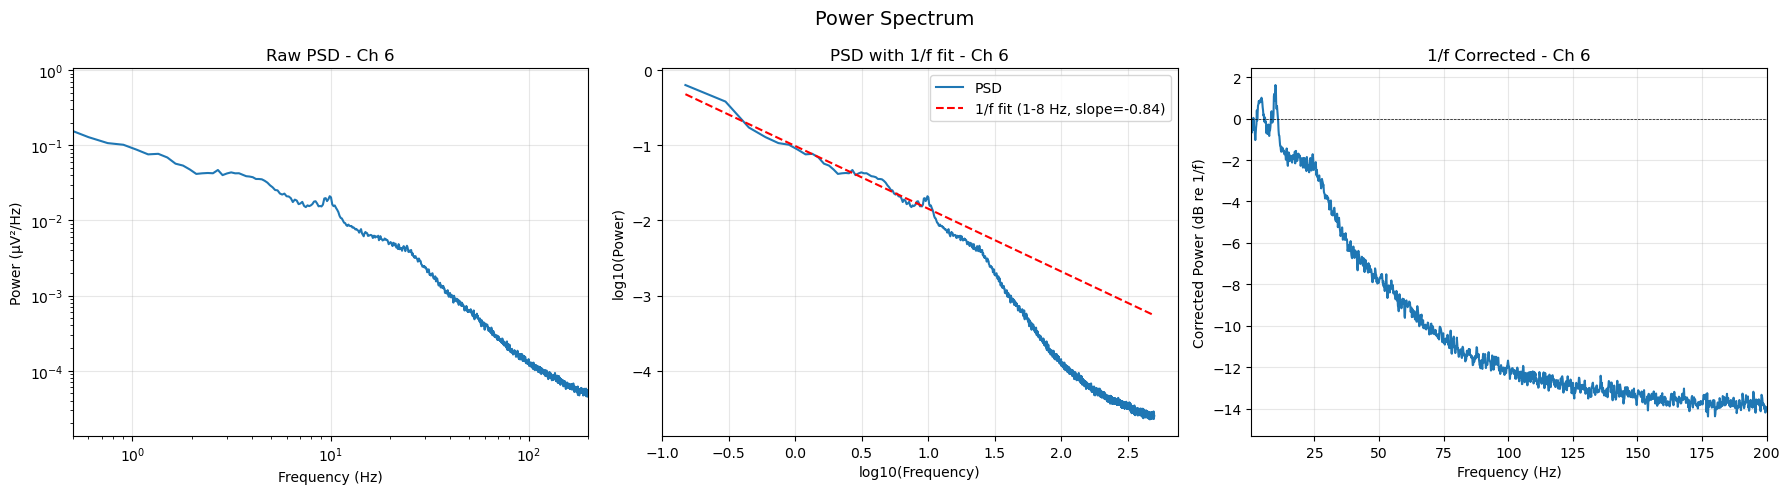

Frequency resolution: 0.150 Hz
1/f slope: -0.835
1/f fit band: 1-8 Hz


In [24]:
plot_power_corrected(all_long_combined)

In [25]:
def plot_power_average(
    all_data,
    fs=1000,
    nperseg=6667,
    output_dir=None,
    fit_range=(1, 200),
    line_freq=60,
    line_exclusion_hz=2,
):
    n_channels = 128
    ch_signals = {ch: [] for ch in range(n_channels)}

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            broadband = mat_file['BroadbandData']
            for bin_data in broadband:
                n_samp = len(bin_data) // n_channels
                reshaped = bin_data[:n_channels * n_samp].reshape(n_channels, n_samp)
                for ch in range(n_channels):
                    ch_signals[ch].append(reshaped[ch, :])

    all_psds = []
    for ch in range(n_channels):
        signal = np.concatenate(ch_signals[ch])
        freqs, psd = welch(signal, fs=fs, nperseg=nperseg)
        all_psds.append(psd)

    all_psds = np.array(all_psds)
    mean_psd = np.mean(all_psds, axis=0)

    mask = freqs > 0
    freqs_pos = freqs[mask]
    log_f = np.log10(freqs_pos)
    log_p = np.log10(mean_psd[mask])

    fit_mask = (freqs_pos >= fit_range[0]) & (freqs_pos <= fit_range[1])

    if line_freq is not None and line_freq > 0:
        max_harmonic = int(freqs_pos.max() // line_freq)
        for k in range(1, max_harmonic + 1):
            harmonic = k * line_freq
            fit_mask &= np.abs(freqs_pos - harmonic) > line_exclusion_hz

    if np.sum(fit_mask) < 2:
        raise ValueError(
            f"Not enough points for 1/f fit. Check fit_range={fit_range} and exclusions."
        )

    slope, intercept, _, _, _ = linregress(log_f[fit_mask], log_p[fit_mask])
    fit_line = slope * log_f + intercept
    corrected_db = 10 * (log_p - fit_line)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].loglog(freqs_pos, mean_psd[mask])
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].set_title('Raw PSD (mean across all channels)')
    axes[0].set_xlim([0.5, 200])
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log_f, log_p, label='Log PSD')
    axes[1].plot(log_f, fit_line, 'r--', label=f'1/f fit ({fit_range[0]}-{fit_range[1]} Hz, slope={slope:.2f})')
    axes[1].set_xlabel('log10(Frequency)')
    axes[1].set_ylabel('log10(Power)')
    axes[1].set_title('Log Power + 1/f Fit (average)')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(freqs_pos, corrected_db)
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Corrected Power (dB re 1/f)')
    axes[2].set_title(f'1/f Corrected (slope={slope:.2f})')
    axes[2].set_xlim([0.5, 200])
    axes[2].axhline(0, color='k', linestyle='--', linewidth=0.5)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle('Long Session - All Channels Averaged', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if output_dir:
        fpath = os.path.join(output_dir, "Power_Average.png")
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Resolution: {freqs[1]-freqs[0]:.3f} Hz")
    print(f"1/f slope: {slope:.3f}")
    print(f"1/f fit band: {fit_range[0]}-{fit_range[1]} Hz")

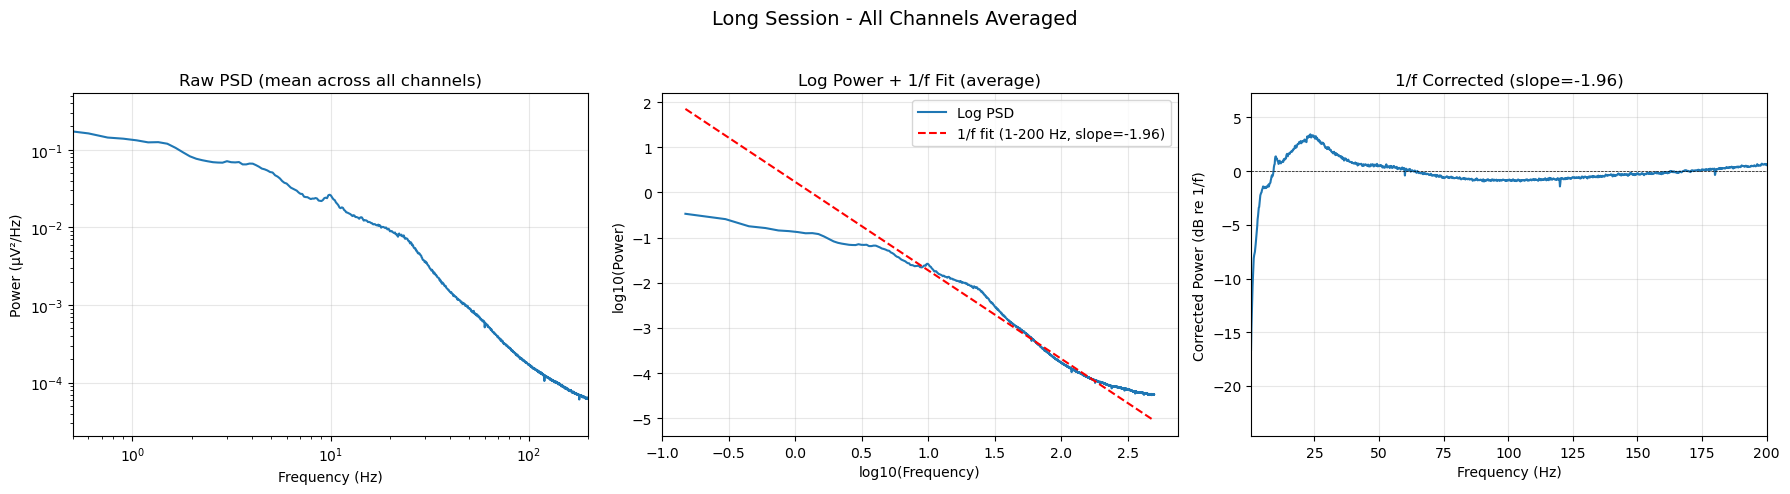

Resolution: 0.150 Hz
1/f slope: -1.959
1/f fit band: 1-200 Hz


In [26]:
plot_power_average(all_long_combined)

In [23]:
def get_bin_lengths(all_data, n_channels=128):
    """Collect bin lengths in samples-per-channel across all files."""
    lengths = []
    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            for bin_data in mat_file['BroadbandData']:
                lengths.append(len(bin_data) // n_channels)
    return np.array(lengths, dtype=int)


def summarize_nperseg_choice(all_data, chosen_nperseg, n_channels=128):
    """Report how a user-chosen nperseg interacts with bin lengths."""
    bin_lengths = get_bin_lengths(all_data, n_channels=n_channels)
    if len(bin_lengths) == 0:
        raise ValueError('No bins found in dataset.')

    valid_bins = np.sum(bin_lengths >= chosen_nperseg)
    total_bins = len(bin_lengths)
    print(f'Bin length range: {bin_lengths.min()} to {bin_lengths.max()} samples/channel')
    print(f'Selected nperseg = {chosen_nperseg}')
    print(f'Valid bins: {valid_bins}/{total_bins} ({100 * valid_bins / total_bins:.1f}%)')
    print(f'Frequency resolution: {1000 / chosen_nperseg:.3f} Hz')
    return bin_lengths


def compute_file_psd(mat_file, channel=1, fs=1000, nperseg=6667, average_bins=True):
    """Compute PSD(s) for one file from BroadbandData using a fixed nperseg.

    If average_bins=True, returns one PSD averaged across valid bins in the file.
    Otherwise returns one PSD per valid bin.
    """
    n_channels = 128
    broadband = mat_file['BroadbandData']
    bin_psds = []
    freqs_ref = None
    skipped_bins = 0

    for bin_data in broadband:
        n_samples = len(bin_data) // n_channels
        if n_samples < nperseg:
            skipped_bins += 1
            continue

        reshaped = bin_data[: n_channels * n_samples].reshape(n_channels, n_samples)
        signal_1d = reshaped[channel - 1, :]
        freqs, psd = welch(signal_1d, fs=fs, nperseg=nperseg)

        if freqs_ref is None:
            freqs_ref = freqs
        elif len(freqs) != len(freqs_ref) or not np.allclose(freqs, freqs_ref):
            raise ValueError('Inconsistent frequency grids across bins even with fixed nperseg.')

        bin_psds.append(psd)

    if not bin_psds:
        raise ValueError(f'No valid bins for this file with nperseg={nperseg}.')

    bin_psds = np.array(bin_psds)

    if average_bins:
        return freqs_ref, np.mean(bin_psds, axis=0), skipped_bins, len(broadband)
    return freqs_ref, bin_psds, skipped_bins, len(broadband)


def collect_file_psds(all_data, channel=1, fs=1000, nperseg=6667):
    """Compute one PSD per file by averaging Welch PSDs across valid bins."""
    file_psds = []
    file_labels = []
    freqs_ref = None
    file_stats = []

    for subj_id, subj_files in all_data.items():
        for fname, mat_file in subj_files.items():
            try:
                freqs, mean_psd, skipped_bins, total_bins = compute_file_psd(
                    mat_file,
                    channel=channel,
                    fs=fs,
                    nperseg=nperseg,
                    average_bins=True,
                )
                if freqs_ref is None:
                    freqs_ref = freqs
                elif len(freqs) != len(freqs_ref) or not np.allclose(freqs, freqs_ref):
                    raise ValueError('Inconsistent frequency grids across files.')

                file_psds.append(mean_psd)
                label = f'{subj_id}/{fname}'
                file_labels.append(label)
                file_stats.append({
                    'label': label,
                    'used_bins': total_bins - skipped_bins,
                    'skipped_bins': skipped_bins,
                    'total_bins': total_bins,
                })
            except Exception as exc:
                print(f'Skipping {subj_id}/{fname}: {exc}')

    if not file_psds:
        raise ValueError('No PSDs were computed.')

    return freqs_ref, np.array(file_psds), file_labels, file_stats

In [26]:
# User-controlled Welch window length
selected_nperseg = 150
print(f'Selected nperseg = {selected_nperseg}')

Selected nperseg = 150


In [1]:
# Average PSD across files, then fit FOOOF to that average
channel = 2
bin_lengths = summarize_nperseg_choice(all_long_combined, selected_nperseg)
freqs_files, file_psds, file_labels, file_stats = collect_file_psds(
    all_long_combined,
    channel=channel,
    nperseg=selected_nperseg,
)
mean_file_psd = np.mean(file_psds, axis=0)
std_file_psd = np.std(file_psds, axis=0)

used_bins = sum(item['used_bins'] for item in file_stats)
skipped_bins = sum(item['skipped_bins'] for item in file_stats)
total_bins = sum(item['total_bins'] for item in file_stats)

# Match peak width limits to spectral resolution
freq_resolution = 1000 / selected_nperseg
peak_width_low = max(2 * freq_resolution, 2.0)
peak_width_high = max(peak_width_low + 2.0, 12.0)

fm_avg = FOOOF(
    peak_width_limits=[peak_width_low, peak_width_high],
    max_n_peaks=6,
    min_peak_height=0.1,
)
fm_avg.fit(freqs_files, mean_file_psd, freq_range=[1, 200])

print(f'Computed PSDs for {len(file_labels)} files on channel {channel}')
print(f'Selected nperseg used: {selected_nperseg}')
print(f'Used bins: {used_bins}/{total_bins} | Skipped bins: {skipped_bins}')
print(f'FOOOF peak width limits: [{peak_width_low:.2f}, {peak_width_high:.2f}] Hz')
print('Average-PSD aperiodic params:', fm_avg.get_params('aperiodic_params'))
print('Average-PSD peak params:')
print(fm_avg.get_params('peak_params'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(freqs_files, mean_file_psd, color='k', label='Mean PSD across files')
axes[0].fill_between(
    freqs_files,
    np.maximum(mean_file_psd - std_file_psd, 1e-20),
    mean_file_psd + std_file_psd,
    color='gray',
    alpha=0.25,
    label='±1 SD across files',
)
axes[0].set_xlim([1, 200])
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power')
axes[0].set_title('Average PSD Across Files')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

fm_avg.plot(plot_peaks='shade', add_legend=True, ax=axes[1])
axes[1].set_title('FOOOF Fit to Average PSD')
plt.tight_layout()
plt.show()

NameError: name 'summarize_nperseg_choice' is not defined

FOOOF failed for 20220429/105659/Data0018.mat: too many indices for array: array is 1-dimensional, but 2 were indexed
Successfully fit FOOOF on 365 files
FOOOF peak width limits: [13.33, 15.33] Hz
Mean exponent: 1.740 +/- 0.132
Files with gamma peaks (70-150 Hz): 148/365
Mean gamma peak power: 0.189 +/- 0.060


FOOOF failed for 20220429/105659/Data0018.mat: too many indices for array: array is 1-dimensional, but 2 were indexed
Successfully fit FOOOF on 365 files
FOOOF peak width limits: [13.33, 15.33] Hz
Mean exponent: 1.740 +/- 0.132
Files with gamma peaks (70-150 Hz): 148/365
Mean gamma peak power: 0.189 +/- 0.060


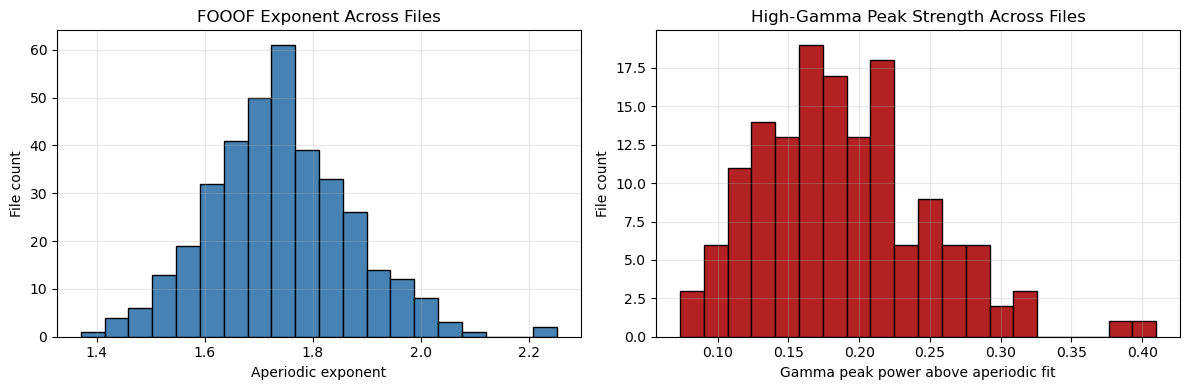


Top files by gamma peak power:
20220427/104443/Data0007.mat: gamma_cf=134.18 Hz, gamma_power=0.410, exponent=1.600, R2=0.990
20220309/111051/Data0021.mat: gamma_cf=143.57 Hz, gamma_power=0.379, exponent=1.587, R2=0.965
20220309/111313/Data0003.mat: gamma_cf=122.41 Hz, gamma_power=0.314, exponent=1.612, R2=0.979
20220309/111051/Data0014.mat: gamma_cf=136.00 Hz, gamma_power=0.314, exponent=1.744, R2=0.988
20220427/104824/Data0006.mat: gamma_cf=122.14 Hz, gamma_power=0.310, exponent=1.701, R2=0.991
20220309/111051/Data0019.mat: gamma_cf=134.85 Hz, gamma_power=0.303, exponent=1.876, R2=0.976
20220429/105659/Data0012.mat: gamma_cf=149.81 Hz, gamma_power=0.299, exponent=1.850, R2=0.985
20220427/103604/Data0012.mat: gamma_cf=130.32 Hz, gamma_power=0.290, exponent=1.445, R2=0.973
20220316/105537/Data0002.mat: gamma_cf=147.26 Hz, gamma_power=0.287, exponent=1.791, R2=0.989
20220429/105659/Data0010.mat: gamma_cf=143.52 Hz, gamma_power=0.286, exponent=1.837, R2=0.975


In [28]:
# Fit FOOOF per file and summarize across files
per_file_results = []

freq_resolution = 1000 / selected_nperseg
peak_width_low = max(2 * freq_resolution, 2.0)
peak_width_high = max(peak_width_low + 2.0, 12.0)

for label, file_psd in zip(file_labels, file_psds):
    fm_file = FOOOF(
        peak_width_limits=[peak_width_low, peak_width_high],
        max_n_peaks=6,
        min_peak_height=0.1,
    )
    try:
        fm_file.fit(freqs_files, file_psd, freq_range=[1, 200])
        ap_params = fm_file.get_params('aperiodic_params')
        peak_params = fm_file.get_params('peak_params')

        gamma_peak_power = np.nan
        gamma_peak_cf = np.nan
        if peak_params is not None and len(peak_params) > 0:
            gamma_peaks = peak_params[(peak_params[:, 0] >= 70) & (peak_params[:, 0] <= 150)]
            if len(gamma_peaks) > 0:
                best_peak = gamma_peaks[np.argmax(gamma_peaks[:, 1])]
                gamma_peak_cf = best_peak[0]
                gamma_peak_power = best_peak[1]

        per_file_results.append({
            'label': label,
            'offset': ap_params[0],
            'exponent': ap_params[-1],
            'n_peaks': 0 if peak_params is None else len(peak_params),
            'gamma_peak_cf': gamma_peak_cf,
            'gamma_peak_power': gamma_peak_power,
            'r_squared': fm_file.r_squared_,
            'error': fm_file.error_,
        })
    except Exception as exc:
        print(f'FOOOF failed for {label}: {exc}')

print(f'Successfully fit FOOOF on {len(per_file_results)} files')
print(f'FOOOF peak width limits: [{peak_width_low:.2f}, {peak_width_high:.2f}] Hz')

if per_file_results:
    exponents = np.array([row['exponent'] for row in per_file_results], dtype=float)
    gamma_powers = np.array([row['gamma_peak_power'] for row in per_file_results], dtype=float)
    valid_gamma = np.isfinite(gamma_powers)

    print(f"Mean exponent: {np.nanmean(exponents):.3f} +/- {np.nanstd(exponents):.3f}")
    print(f"Files with gamma peaks (70-150 Hz): {np.sum(valid_gamma)}/{len(gamma_powers)}")
    if np.any(valid_gamma):
        print(f"Mean gamma peak power: {np.nanmean(gamma_powers[valid_gamma]):.3f} +/- {np.nanstd(gamma_powers[valid_gamma]):.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(exponents, bins=20, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Aperiodic exponent')
    axes[0].set_ylabel('File count')
    axes[0].set_title('FOOOF Exponent Across Files')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(gamma_powers[valid_gamma], bins=20, color='firebrick', edgecolor='black')
    axes[1].set_xlabel('Gamma peak power above aperiodic fit')
    axes[1].set_ylabel('File count')
    axes[1].set_title('High-Gamma Peak Strength Across Files')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    top_gamma = sorted(
        [row for row in per_file_results if np.isfinite(row['gamma_peak_power'])],
        key=lambda row: row['gamma_peak_power'],
        reverse=True,
    )[:10]
    print('\nTop files by gamma peak power:')
    for row in top_gamma:
        print(
            f"{row['label']}: gamma_cf={row['gamma_peak_cf']:.2f} Hz, "
            f"gamma_power={row['gamma_peak_power']:.3f}, exponent={row['exponent']:.3f}, "
            f"R2={row['r_squared']:.3f}"
        )

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_87503/4110244033.py:21: RuntimeWarning: divide by zero encountered in log10
  ap_log_file = offset - exponent * np.log10(freqs_files)
/var/folders/pc/kr77rnc562z4p366739

Computed average residual curve from 366 files
Selected nperseg used: 150
FOOOF peak width limits: [13.33, 15.33] Hz
High-gamma mean distance: -0.039 dB
High-gamma peak mean distance: 0.547 dB


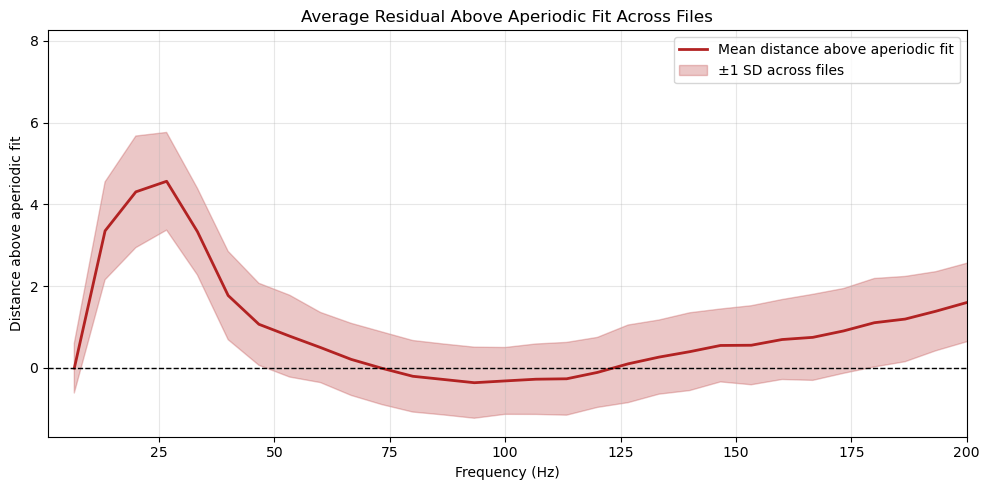

In [31]:
# Average residual above the aperiodic fit across files, with ±1 SD
residual_curves_db = []
used_labels = []

freq_resolution = 1000 / selected_nperseg
peak_width_low = max(2 * freq_resolution, 2.0)
peak_width_high = max(peak_width_low + 2.0, 12.0)

for label, file_psd in zip(file_labels, file_psds):
    fm_file = FOOOF(
        peak_width_limits=[peak_width_low, peak_width_high],
        max_n_peaks=6,
        min_peak_height=0.1,
    )
    try:
        fm_file.fit(freqs_files, file_psd, freq_range=[1, 200])
        ap_params = fm_file.get_params('aperiodic_params')

        if len(ap_params) == 2:
            offset, exponent = ap_params
            ap_log_file = offset - exponent * np.log10(freqs_files)
        elif len(ap_params) == 3:
            offset, knee, exponent = ap_params
            ap_log_file = offset - np.log10(knee + freqs_files**exponent)
        else:
            raise ValueError(f'Unexpected aperiodic params: {ap_params}')

        resid_db_file = 10 * (np.log10(file_psd) - ap_log_file)
        residual_curves_db.append(resid_db_file)
        used_labels.append(label)
    except Exception as exc:
        print(f'Skipping residual curve for {label}: {exc}')

residual_curves_db = np.array(residual_curves_db)
mean_resid_db = np.mean(residual_curves_db, axis=0)
std_resid_db = np.std(residual_curves_db, axis=0)

hg_mask = (freqs_files >= 70) & (freqs_files <= 150)
for harmonic in [60, 120, 180]:
    hg_mask &= np.abs(freqs_files - harmonic) > 2

print(f'Computed average residual curve from {len(used_labels)} files')
print(f'Selected nperseg used: {selected_nperseg}')
print(f'FOOOF peak width limits: [{peak_width_low:.2f}, {peak_width_high:.2f}] Hz')
print(f'High-gamma mean distance: {np.mean(mean_resid_db[hg_mask]):.3f} dB')
print(f'High-gamma peak mean distance: {np.max(mean_resid_db[hg_mask]):.3f} dB')

plt.figure(figsize=(10, 5))
plt.plot(freqs_files, mean_resid_db, color='firebrick', linewidth=2, label='Mean distance above aperiodic fit')
plt.fill_between(
    freqs_files,
    mean_resid_db - std_resid_db,
    mean_resid_db + std_resid_db,
    color='firebrick',
    alpha=0.25,
    label='±1 SD across files',
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlim([1, 200])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Distance above aperiodic fit')
plt.title('Average Residual Above Aperiodic Fit Across Files')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Subfile done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File done
File do

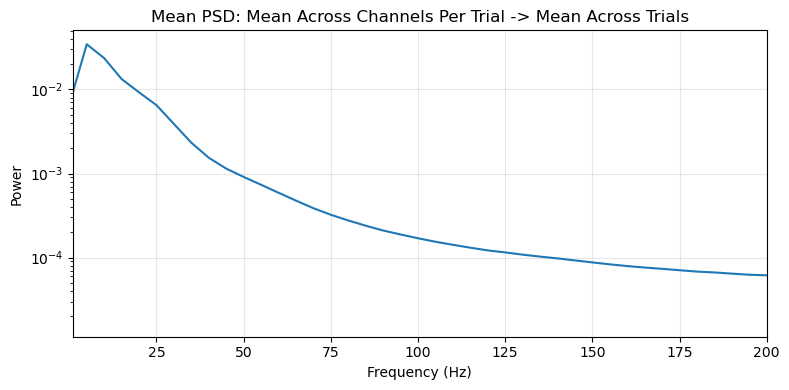

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 200

trial_psds = []
freqs_ref = None
skipped_trials = 0

for subj_files in all_data.values():
    print("Subfile done")
    for mat_file in subj_files.values():
        for bin_data in mat_file["BroadbandData"]:
            n_samples = len(bin_data) // n_channels
            if n_samples < nperseg:
                skipped_trials += 1
                continue

            reshaped = bin_data[: n_channels * n_samples].reshape(n_channels, n_samples)

            # Mean PSD across channels for this trial
            ch_psds = []
            for ch in range(n_channels):
                freqs, psd = welch(reshaped[ch], fs=fs, nperseg=nperseg)
                ch_psds.append(psd)

            trial_psd = np.mean(ch_psds, axis=0)
            trial_psds.append(trial_psd)

            if freqs_ref is None:
                freqs_ref = freqs
            print("File done")

if len(trial_psds) == 0:
    raise ValueError(f"No valid trials found. Try smaller nperseg (current: {nperseg}).")

# Mean of trial means
mean_psd = np.mean(trial_psds, axis=0)

print(f"Used trials: {len(trial_psds)}")
print(f"Skipped short trials: {skipped_trials}")

plt.figure(figsize=(8, 4))
plt.semilogy(freqs_ref, mean_psd)
plt.xlim(1, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Mean PSD: Mean Across Channels Per Trial -> Mean Across Trials")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()